# PyTorch ile Hisse Senedi Fiyat Tahmini: LSTM vs GRU

Amaç, Apple (AAPL) hisse senedinin kapanış fiyatını tahmin etmek. 20 günlük sliding window kullanılarak iki RNN modeli karşılaştırılıyor. Multi-feature (Open, High, Low, Close, Volume) yaklaşımı.

Veri: Yahoo Finance, 2019-2024

Uyarı: Bu proje eğitim amaçlıdır, yatırım tavsiyesi değildir.

## İçindekiler
1. Kütüphaneler ve Ortam Kurulumu
2. Veri Yükleme ve Doğrulama
3. Keşifsel Veri Analizi (EDA)
4. Veri Ön İşleme (Leakage-Safe)
5. LSTM ve GRU Model Tanımları
6. Model Eğitimi
7. Değerlendirme ve Karşılaştırma
8. Sonuçlar ve Değerlendirme

## 1. Kütüphaneler ve Ortam Kurulumu
Seed sabitleme işlemleri yapılıyor ve model eğitimi için uygun donanım (GPU/CPU) seçimi gerçekleştiriliyor.

In [1]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(f'PyTorch Surumu: {torch.__version__}')
print(f'Cihaz: {DEVICE}')
print(f'CUDA Kullanilabilir: {torch.cuda.is_available()}')

PyTorch Surumu: 2.13.0+cpu
Cihaz: cpu
CUDA Kullanilabilir: False


## 2. Veri Yükleme ve Doğrulama
AAPL verisi yfinance ile indirilir veya daha önce indirildiyse CSV'den okunur. 5 özellik sütunu (Open, High, Low, Close, Volume) kullanılır ve doğrulanır.

In [2]:
TICKER = 'AAPL'
START_DATE = '2019-01-01'
END_DATE = '2024-01-01'
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / 'aapl_2019_2024.csv'

def download_stock_data(ticker, start, end):
    try:
        import yfinance as yf
    except ImportError:
        raise RuntimeError(
            'yfinance yuklu degil. Lutfen `pip install yfinance` komutunu calistirin.'
        )
    kwargs = dict(tickers=ticker, start=start, end=end, auto_adjust=False, progress=False)
    try:
        frame = yf.download(**kwargs, multi_level_index=False)
    except TypeError:
        frame = yf.download(**kwargs)
    if frame.empty:
        raise RuntimeError('Yahoo Finance veri dondurmedi.')
    if isinstance(frame.columns, pd.MultiIndex):
        if ticker in frame.columns.get_level_values(-1):
            frame = frame.xs(ticker, axis=1, level=-1)
        else:
            frame.columns = frame.columns.get_level_values(0)
    frame = frame.reset_index()
    frame.to_csv(DATA_PATH, index=False)
    return frame

def load_and_validate_data():
    if DATA_PATH.exists():
        frame = pd.read_csv(DATA_PATH)
        kaynak = f'Yerel dosya ({DATA_PATH})'
    else:
        frame = download_stock_data(TICKER, START_DATE, END_DATE)
        kaynak = 'Yahoo Finance'
    frame.columns = [str(c).strip() for c in frame.columns]
    date_col = 'Date' if 'Date' in frame.columns else frame.columns[0]
    frame[date_col] = pd.to_datetime(frame[date_col], utc=True).dt.tz_localize(None)
    frame = frame.rename(columns={date_col: 'Date'}).set_index('Date').sort_index()
    required = {'Open', 'High', 'Low', 'Close', 'Volume'}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f'Eksik sutunlar: {sorted(missing)}')
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors='coerce')
    if frame[numeric_cols].isna().any().any():
        raise ValueError('Eksik veya sayisal olmayan OHLCV degerleri bulundu.')
    if (frame[['Open', 'High', 'Low', 'Close']] <= 0).any().any():
        raise ValueError('Fiyatlar pozitif olmalidir.')
    print(f'Kaynak: {kaynak}')
    print(f'Satir sayisi: {len(frame):,}')
    print(f'Tarih araligi: {frame.index.min().date()} - {frame.index.max().date()}')
    return frame

stock = load_and_validate_data()
stock.head()

Kaynak: Yahoo Finance
Satir sayisi: 1,258
Tarih araligi: 2019-01-02 - 2023-12-29


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2019-01-02,37.469200,39.480000,39.712502,38.557499,38.722500,148158800
2019-01-03,33.736996,35.547501,36.430000,35.500000,35.994999,365248800
2019-01-04,35.177204,37.064999,37.137501,35.950001,36.132500,234428400
2019-01-07,35.098904,36.982498,37.207500,36.474998,37.174999,219111200
2019-01-08,35.767994,37.687500,37.955002,37.130001,37.389999,164101200


## 3. Keşifsel Veri Analizi (EDA)
Bu bölümde verileri görselleştirip anlıyoruz. İstatistiksel özet, fiyat grafiği, hareketli ortalamalar, hacim analizi ve korelasyon matrisi.

In [3]:
print('=== Istatistiksel Ozet ===')
display(stock.describe().T.style.format('{:,.2f}'))

=== Istatistiksel Ozet ===


,count,mean,std,min,25%,50%,75%,max
Adj Close,"1,258.00",120.21,46.29,33.74,74.55,131.17,156.44,195.89
Close,"1,258.00",123.03,46.53,35.55,77.38,134.61,159.67,198.11
High,"1,258.00",124.32,46.94,36.43,78.00,136.00,162.12,199.62
Low,"1,258.00",121.60,46.09,35.50,76.11,133.33,157.71,197.00
Open,"1,258.00",122.91,46.51,35.99,76.86,134.79,159.73,198.02
Volume,"1,258.00","101,591,729.65","52,610,454.46","24,048,300.00","68,030,125.00","88,617,400.00","118,978,600.00","426,510,000.00"


### 3.1 Kapanış Fiyatı Grafiği
Zaman serisinin kapanış fiyatı seyrini incelemek için temel grafik.

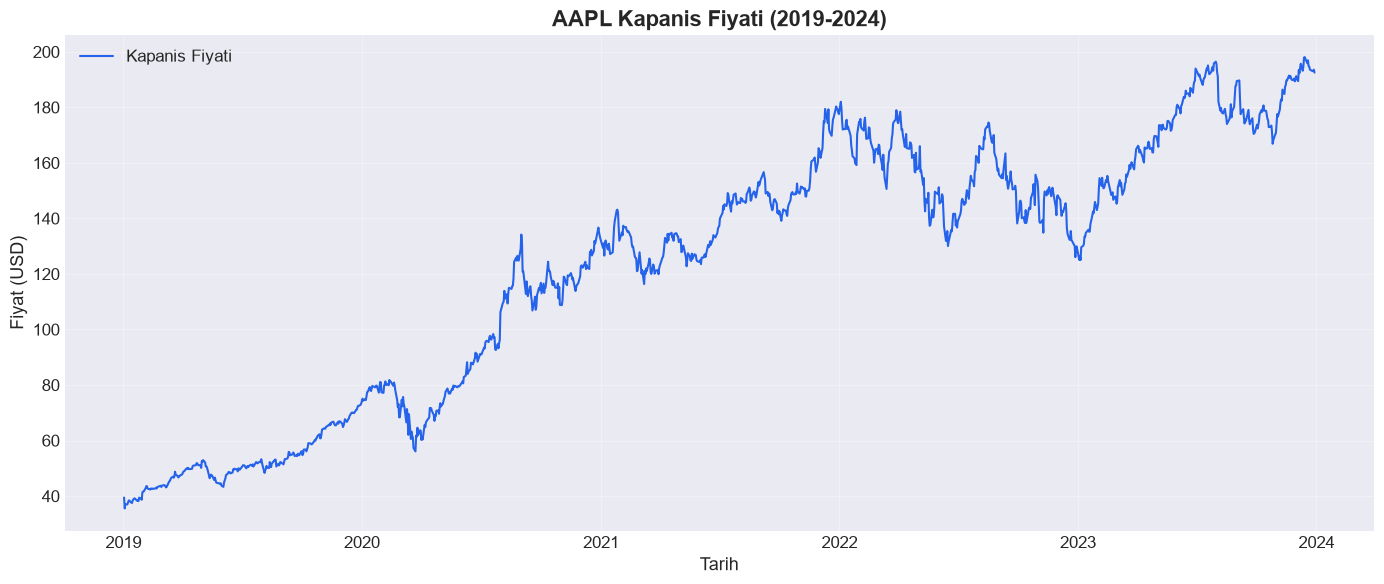

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(stock.index, stock['Close'], color='#2563eb', linewidth=1.5, label='Kapanis Fiyati')
ax.set_title(f'{TICKER} Kapanis Fiyati (2019-2024)', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=13)
ax.set_ylabel('Fiyat (USD)', fontsize=13)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 3.2 Hareketli Ortalamalar
20, 50 ve 200 günlük hareketli ortalamalar (SMA) fiyat trendlerini analiz etmek için kullanılır.

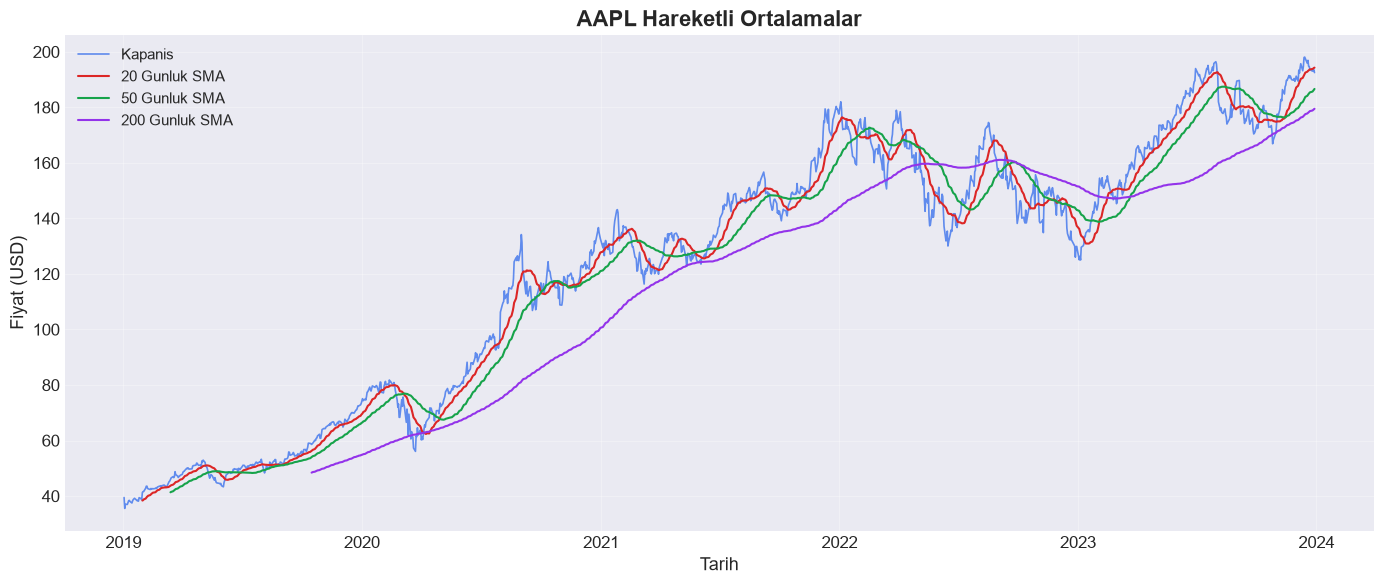

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(stock.index, stock['Close'], color='#2563eb', linewidth=1.2, alpha=0.7, label='Kapanis')
for window, color in [(20, '#dc2626'), (50, '#16a34a'), (200, '#9333ea')]:
    sma = stock['Close'].rolling(window=window).mean()
    ax.plot(stock.index, sma, color=color, linewidth=1.5, label=f'{window} Gunluk SMA')
ax.set_title(f'{TICKER} Hareketli Ortalamalar', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=13)
ax.set_ylabel('Fiyat (USD)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 3.3 İşlem Hacmi
İşlem hacmi, piyasa aktivitesini gösterir.

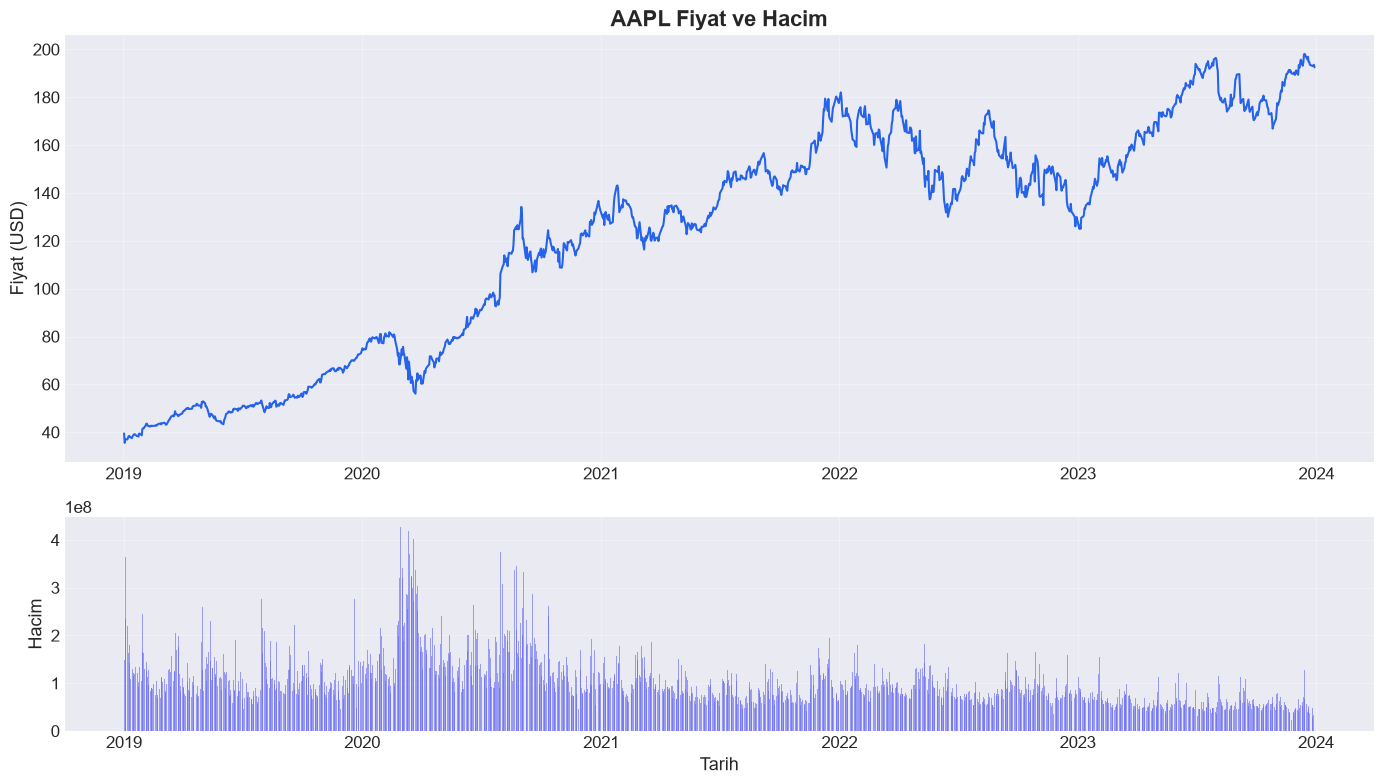

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
ax1.plot(stock.index, stock['Close'], color='#2563eb', linewidth=1.5)
ax1.set_title(f'{TICKER} Fiyat ve Hacim', fontsize=16, fontweight='bold')
ax1.set_ylabel('Fiyat (USD)', fontsize=13)
ax1.grid(alpha=0.3)
ax2.bar(stock.index, stock['Volume'], color='#6366f1', alpha=0.6, width=1.5)
ax2.set_ylabel('Hacim', fontsize=13)
ax2.set_xlabel('Tarih', fontsize=13)
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 3.4 Korelasyon Matrisi
Özellikler arasındaki ilişkiyi analiz etmek.

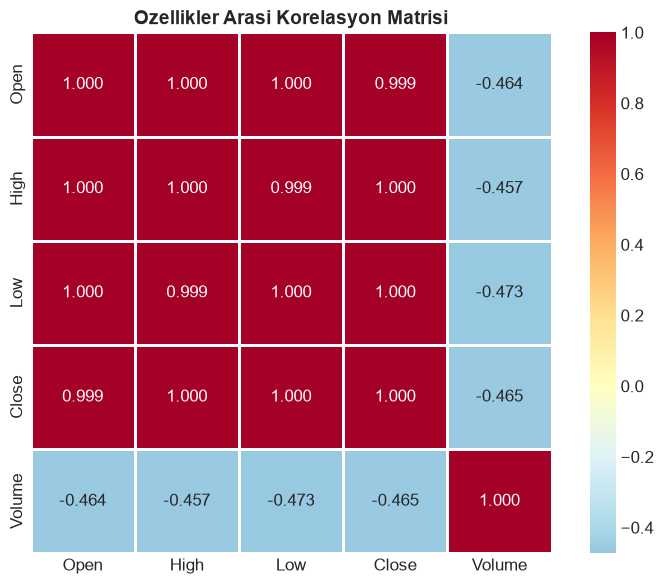

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = stock[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title('Ozellikler Arasi Korelasyon Matrisi', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## 4. Veri Ön İşleme (Leakage-Safe)
Veri sızıntısını önlemek için scaler sadece eğitim verisine fit edilir. 5 özellik (Open, High, Low, Close, Volume) kullanılarak 20 günlük pencereler oluşturulur. Hedef değişken: Close.

In [8]:
FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET_COL = 'Close'
WINDOW_SIZE = 20
TRAIN_RATIO = 0.80
BATCH_SIZE = 64

feature_data = stock[FEATURE_COLS].values
close_idx = FEATURE_COLS.index(TARGET_COL)

# Kronolojik train/test bolme
split_point = int(len(feature_data) * TRAIN_RATIO)
train_data = feature_data[:split_point]
test_data = feature_data[split_point:]

print(f'Egitim seti: {len(train_data):,} gun')
print(f'Test seti: {len(test_data):,} gun')
print(f'Pencere boyutu: {WINDOW_SIZE} gun')
print(f'Ozellik sayisi: {len(FEATURE_COLS)}')

# Scaler - sadece egitim verisine fit
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Sliding window olusturma
def create_sequences(data, window_size, target_idx):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size, target_idx])
    return np.array(X), np.array(y).reshape(-1, 1)

X_train_np, y_train_np = create_sequences(train_scaled, WINDOW_SIZE, close_idx)
X_test_np, y_test_np = create_sequences(test_scaled, WINDOW_SIZE, close_idx)

# Naive baseline icin gercek degerler
close_values = stock[TARGET_COL].values
train_close = close_values[:split_point]
test_close = close_values[split_point:]
test_positions = np.arange(WINDOW_SIZE, len(test_data))

# Tensor donusumu
X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np)
X_test = torch.FloatTensor(X_test_np)
y_test = torch.FloatTensor(y_test_np)

# DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'\nEgitim ornekleri: {X_train.shape[0]:,}')
print(f'Test ornekleri: {X_test.shape[0]:,}')
print(f'Girdi boyutu: {X_train.shape} (ornek, pencere, ozellik)')
print(f'Hedef boyutu: {y_train.shape}')

Egitim seti: 1,006 gun
Test seti: 252 gun
Pencere boyutu: 20 gun
Ozellik sayisi: 5

Egitim ornekleri: 986
Test ornekleri: 232
Girdi boyutu: torch.Size([986, 20, 5]) (ornek, pencere, ozellik)
Hedef boyutu: torch.Size([986, 1])


## 5. LSTM ve GRU Model Tanımları
- **LSTM (Long Short-Term Memory):** Uzun süreli bağımlılıkları öğrenme yeteneğine sahip, 3 kapı (forget, input, output) mekanizması kullanan RNN.
- **GRU (Gated Recurrent Unit):** LSTM'in basitleştirilmiş versiyonu, 2 kapı (reset, update) ile daha az parametre.
- Her iki modele de **Dropout (0.2)** eklenerek aşırı öğrenme (overfitting) önlenir.
- **5 özellik** girdi olarak alınır, **1 çıktı** (Close fiyatı) üretilir.

In [9]:
class StockLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

class StockGRU(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

lstm_model = StockLSTM().to(DEVICE)
gru_model = StockGRU().to(DEVICE)

print(f'LSTM Parametre Sayisi: {parameter_count(lstm_model):,}')
print(f'GRU Parametre Sayisi: {parameter_count(gru_model):,}')
print(f'\nLSTM Mimarisi:\n{lstm_model}')
print(f'\nGRU Mimarisi:\n{gru_model}')

LSTM Parametre Sayisi: 51,521
GRU Parametre Sayisi: 38,657

LSTM Mimarisi:
StockLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

GRU Mimarisi:
StockGRU(
  (gru): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 6. Model Eğitimi
Her iki model da aynı koşullar altında eğitilir:
- **Optimizer:** Adam (lr=0.001)
- **Loss:** MSE (Mean Squared Error)
- **Epoch:** 100
- **Batch Size:** 64

In [10]:
NUM_EPOCHS = 100
LEARNING_RATE = 0.001

def train_model(model, train_loader, num_epochs, lr, device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        batch_count = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batch_count += 1
        avg_loss = epoch_loss / batch_count
        history.append(avg_loss)
        if (epoch + 1) % 20 == 0:
            print(f'  Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')
    return history

print('LSTM Egitimi Basliyor...')
print('-' * 40)
lstm_start = time.time()
lstm_history = train_model(lstm_model, train_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE)
lstm_seconds = time.time() - lstm_start
print(f'LSTM Egitim Suresi: {lstm_seconds:.2f} saniye\n')

print('GRU Egitimi Basliyor...')
print('-' * 40)
gru_start = time.time()
gru_history = train_model(gru_model, train_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE)
gru_seconds = time.time() - gru_start
print(f'GRU Egitim Suresi: {gru_seconds:.2f} saniye')

LSTM Egitimi Basliyor...
----------------------------------------
  Epoch [20/100], Loss: 0.003902
  Epoch [40/100], Loss: 0.003160
  Epoch [60/100], Loss: 0.002753
  Epoch [80/100], Loss: 0.002510
  Epoch [100/100], Loss: 0.002263
LSTM Egitim Suresi: 153.15 saniye

GRU Egitimi Basliyor...
----------------------------------------
  Epoch [20/100], Loss: 0.003050
  Epoch [40/100], Loss: 0.002703
  Epoch [60/100], Loss: 0.002002
  Epoch [80/100], Loss: 0.001931
  Epoch [100/100], Loss: 0.001987
GRU Egitim Suresi: 172.51 saniye


### Eğitim Kayıp (Loss) Grafiği
Her iki modelin epoch bazında eğitim kaybı (MSE) görüntülenir.

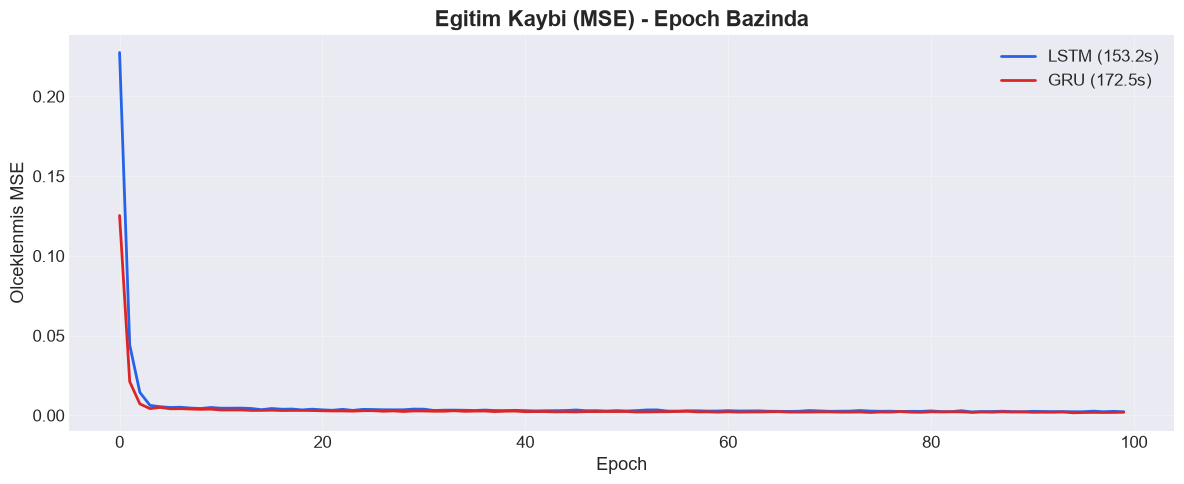

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lstm_history, label=f'LSTM ({lstm_seconds:.1f}s)', color='#2563eb', linewidth=2)
ax.plot(gru_history, label=f'GRU ({gru_seconds:.1f}s)', color='#dc2626', linewidth=2)
ax.set_title('Egitim Kaybi (MSE) - Epoch Bazinda', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Olceklenmis MSE', fontsize=13)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Değerlendirme ve Karşılaştırma
Tahminler USD'ye geri dönüştürülür ve metrikler hesaplanır:
- **MSE:** Büyük hataları güçlü şekilde cezalandırır
- **RMSE:** MSE'nin karekökü, fiyat birimiyle aynı
- **MAE:** Ortalama mutlak hata
- **R² Score:** Modelin açıklama gücü (1'e yakın = iyi)
- **Naive Baseline:** Yarınki fiyat = bugünkü fiyat

In [12]:
def inverse_transform_close(scaled_values, scaler, close_idx):
    dummy = np.zeros((len(scaled_values), scaler.n_features_in_))
    dummy[:, close_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, close_idx]

def predict_usd(model, features, scaler, close_idx):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(features.to(DEVICE)).cpu().numpy()
    return inverse_transform_close(preds_scaled, scaler, close_idx)

def regression_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        'MSE': float(mse),
        'RMSE': float(np.sqrt(mse)),
        'MAE': float(mean_absolute_error(actual, predicted)),
        'R2': float(r2_score(actual, predicted)),
    }

# Gercek degerler
actual_usd = inverse_transform_close(y_test_np, scaler, close_idx)

# Model tahminleri
lstm_predictions = predict_usd(lstm_model, X_test, scaler, close_idx)
gru_predictions = predict_usd(gru_model, X_test, scaler, close_idx)

# Naive baseline
naive_predictions = test_close[test_positions - 1]

# Metrikler
lstm_metrics = regression_metrics(actual_usd, lstm_predictions)
gru_metrics = regression_metrics(actual_usd, gru_predictions)
naive_metrics = regression_metrics(actual_usd, naive_predictions)

print('Metrikler hesaplandi.')

Metrikler hesaplandi.


### Tahmin vs Gerçek Grafikleri
LSTM ve GRU tahminleri gerçek değerlerle karşılaştırılır.

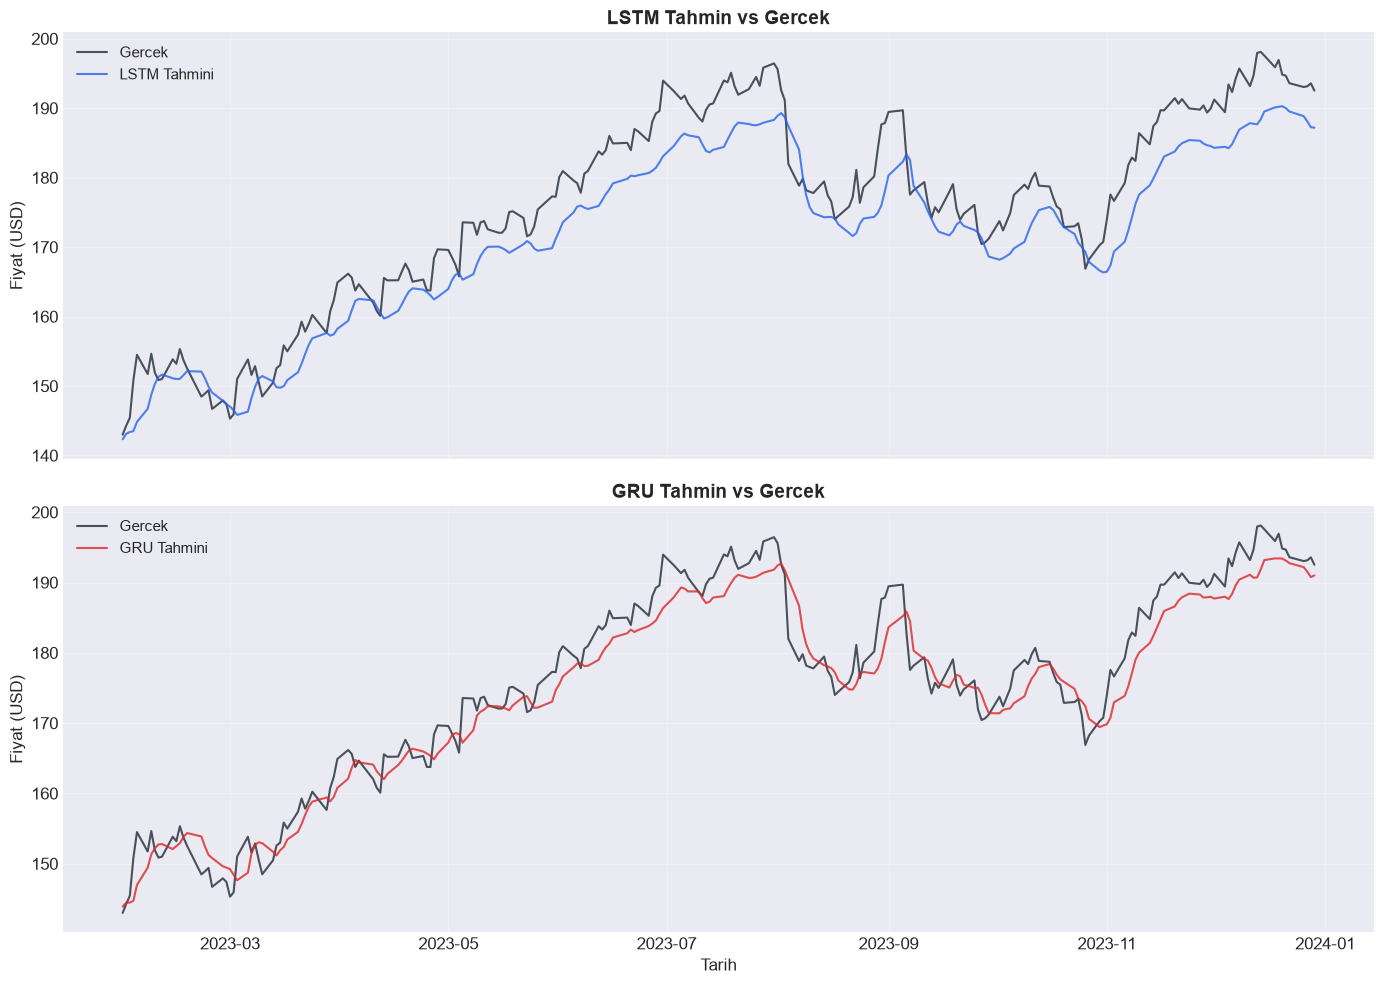

In [13]:
test_dates = stock.index[split_point + WINDOW_SIZE:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, preds, name, color in [
    (axes[0], lstm_predictions, 'LSTM', '#2563eb'),
    (axes[1], gru_predictions, 'GRU', '#dc2626'),
]:
    ax.plot(test_dates, actual_usd, color='#1f2937', linewidth=1.5, label='Gercek', alpha=0.8)
    ax.plot(test_dates, preds, color=color, linewidth=1.5, label=f'{name} Tahmini', alpha=0.8)
    ax.set_title(f'{name} Tahmin vs Gercek', fontsize=14, fontweight='bold')
    ax.set_ylabel('Fiyat (USD)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

axes[1].set_xlabel('Tarih', fontsize=12)
fig.tight_layout()
plt.show()

### Sonuç Tablosu

In [14]:
results = pd.DataFrame([
    {'Model': 'LSTM', **lstm_metrics, 'Egitim Suresi (s)': lstm_seconds, 'Parametre': parameter_count(lstm_model)},
    {'Model': 'GRU', **gru_metrics, 'Egitim Suresi (s)': gru_seconds, 'Parametre': parameter_count(gru_model)},
    {'Model': 'Naive Baseline', **naive_metrics, 'Egitim Suresi (s)': 0.0, 'Parametre': 0},
]).set_index('Model')

print('\n' + '=' * 60)
print('MODEL KARSILASTIRMA TABLOSU')
print('=' * 60)

display(
    results.style.format({
        'MSE': '${:,.2f}',
        'RMSE': '${:,.2f}',
        'MAE': '${:,.2f}',
        'R2': '{:.4f}',
        'Egitim Suresi (s)': '{:,.2f}',
        'Parametre': '{:,.0f}',
    })
)

print('\nEn dusuk MAE:', results['MAE'].idxmin())
print('En yuksek R2:', results['R2'].idxmax())


MODEL KARSILASTIRMA TABLOSU


,MSE,RMSE,MAE,R2,Egitim Suresi (s),Parametre
Model,,,,,,
LSTM,$28.31,$5.32,$4.57,0.8591,153.15,"51,521"
GRU,$10.88,$3.30,$2.74,0.9458,172.51,"38,657"
Naive Baseline,$4.61,$2.15,$1.66,0.9770,0.00,0



En dusuk MAE: Naive Baseline
En yuksek R2: Naive Baseline


## 8. Sonuçlar ve Değerlendirme

Bu çalışmada:

1. **Çoklu Özellik (Multi-Feature) Yaklaşımı:** Open, High, Low, Close ve Volume özelliklerini birlikte kullanarak modellerin daha zengin bilgiye erişmesi sağlandı.

2. **LSTM vs GRU Karşılaştırması:** Her iki model da aynı koşullar altında eğitildi ve karşılaştırıldı.

3. **Dropout ile Regularizasyon:** Aşırı öğrenmeyi önlemek için %20 dropout eklendi.

4. **Naive Baseline:** Modellerin performansı, basit bir baseline ile karşılaştırıldı.

### Sınırlılıklar
- Hisse senedi fiyat tahmini doğası gereği çok zor bir problemdir
- Modeller yalnızca geçmiş fiyat verilerine dayanır, temel/makro analiz içermez
- Tek adımlık tahmin yapılmaktadır
- Hiperparametre optimizasyonu yapılmamıştır

### Gelecek Adımlar
- Attention mekanizması eklenmesi
- Transformer tabanlı modellerin denenmesi
- Teknik indikatörlerin (RSI, MACD vb.) eklenmesi
- Hiperparametre optimizasyonu (Optuna vb.)
- Çoklu adım tahmini

> Bu proje eğitim amaçlıdır. Gerçek yatırım kararları için profesyonel danışmanlık alınmalıdır.